In [ ]:
from google.cloud import bigquery
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
key_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = key_path

client = bigquery.Client()

#eda
query = """
SELECT*
FROM `myetl-474505.ecommerce.pre_events_sample`
"""

df = client.query(query).to_dataframe()
df0=df
df

c:\Users\jiinss\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "unique_count": df.nunique(),
    "dtype": df.dtypes
})

summary

,null_count,unique_count,dtype
event_time,0,384860,"datetime64[us, UTC]"
event_datetime_kst,0,384860,datetime64[us]
event_date,0,32,dbdate
event_year,0,1,Int64
event_month,0,2,Int64
event_day,0,31,Int64
event_week,0,5,Int64
event_isoyear,0,1,Int64
event_dow,0,7,Int64
event_hour,0,24,Int64


In [ ]:
#user
dau=df.groupby("event_date")['user_id'].nunique()
wau=df.groupby("event_week")['user_id'].nunique()

#event
traffic_hour=df.groupby('event_hour').size()
traffic_daily= df.groupby("event_date").size()
traffic_dow=df.groupby('event_dow').size()
traffic_week=df.groupby("event_week").size()

summary = {
    "DAU": dau,
    "WAU": wau,
    "traffic_hour": traffic_hour,
    "traffic_daily":traffic_daily,
    "traffic_dow": traffic_dow,
    "traffic_week": traffic_week
}

for k, v in summary.items():
    print(k)
    display(v.to_frame())

DAU


,user_id
event_date,
2019-10-01,7519
2019-10-02,11233
2019-10-03,10344
2019-10-04,12430
2019-10-05,11917
2019-10-06,11938
2019-10-07,10968
2019-10-08,12094
2019-10-09,12373


WAU


,user_id
event_week,
40,61849
41,82610
42,87999
43,82406
44,46916


traffic_hour


...

,0
event_date,
2019-10-01,8162
2019-10-02,12393
2019-10-03,11415
2019-10-04,13733
2019-10-05,13229
2019-10-06,13213
2019-10-07,12134
2019-10-08,13209
2019-10-09,13599


traffic_dow


,0
event_dow,
1,58083
2,53895
3,63138
4,67547
5,63780
6,61980
7,56654


traffic_week


,0
event_week,
40,72145
41,97563
42,104391
43,96965
44,54013


In [ ]:
print("peak_dau:" ,dau.idxmax(),dau.max())
print("peak_wau:" ,wau.idxmax(),wau.max())
print("peak_traffic_hour:" ,traffic_hour.idxmax(),traffic_hour.max())
print("peak_traffic_daily:" ,traffic_daily.idxmax(),traffic_daily.max())
print("peak_traffic_dow:" ,traffic_dow.idxmax(),traffic_dow.max())
print("peak_traffic_weeek:" ,traffic_week.idxmax(),traffic_week.max())

peak_dau: 2019-10-13 14600
peak_wau: 42 87999
peak_traffic_hour: 1 30776
peak_traffic_daily: 2019-10-13 16318
peak_traffic_dow: 4 67547
peak_traffic_weeek: 42 104391


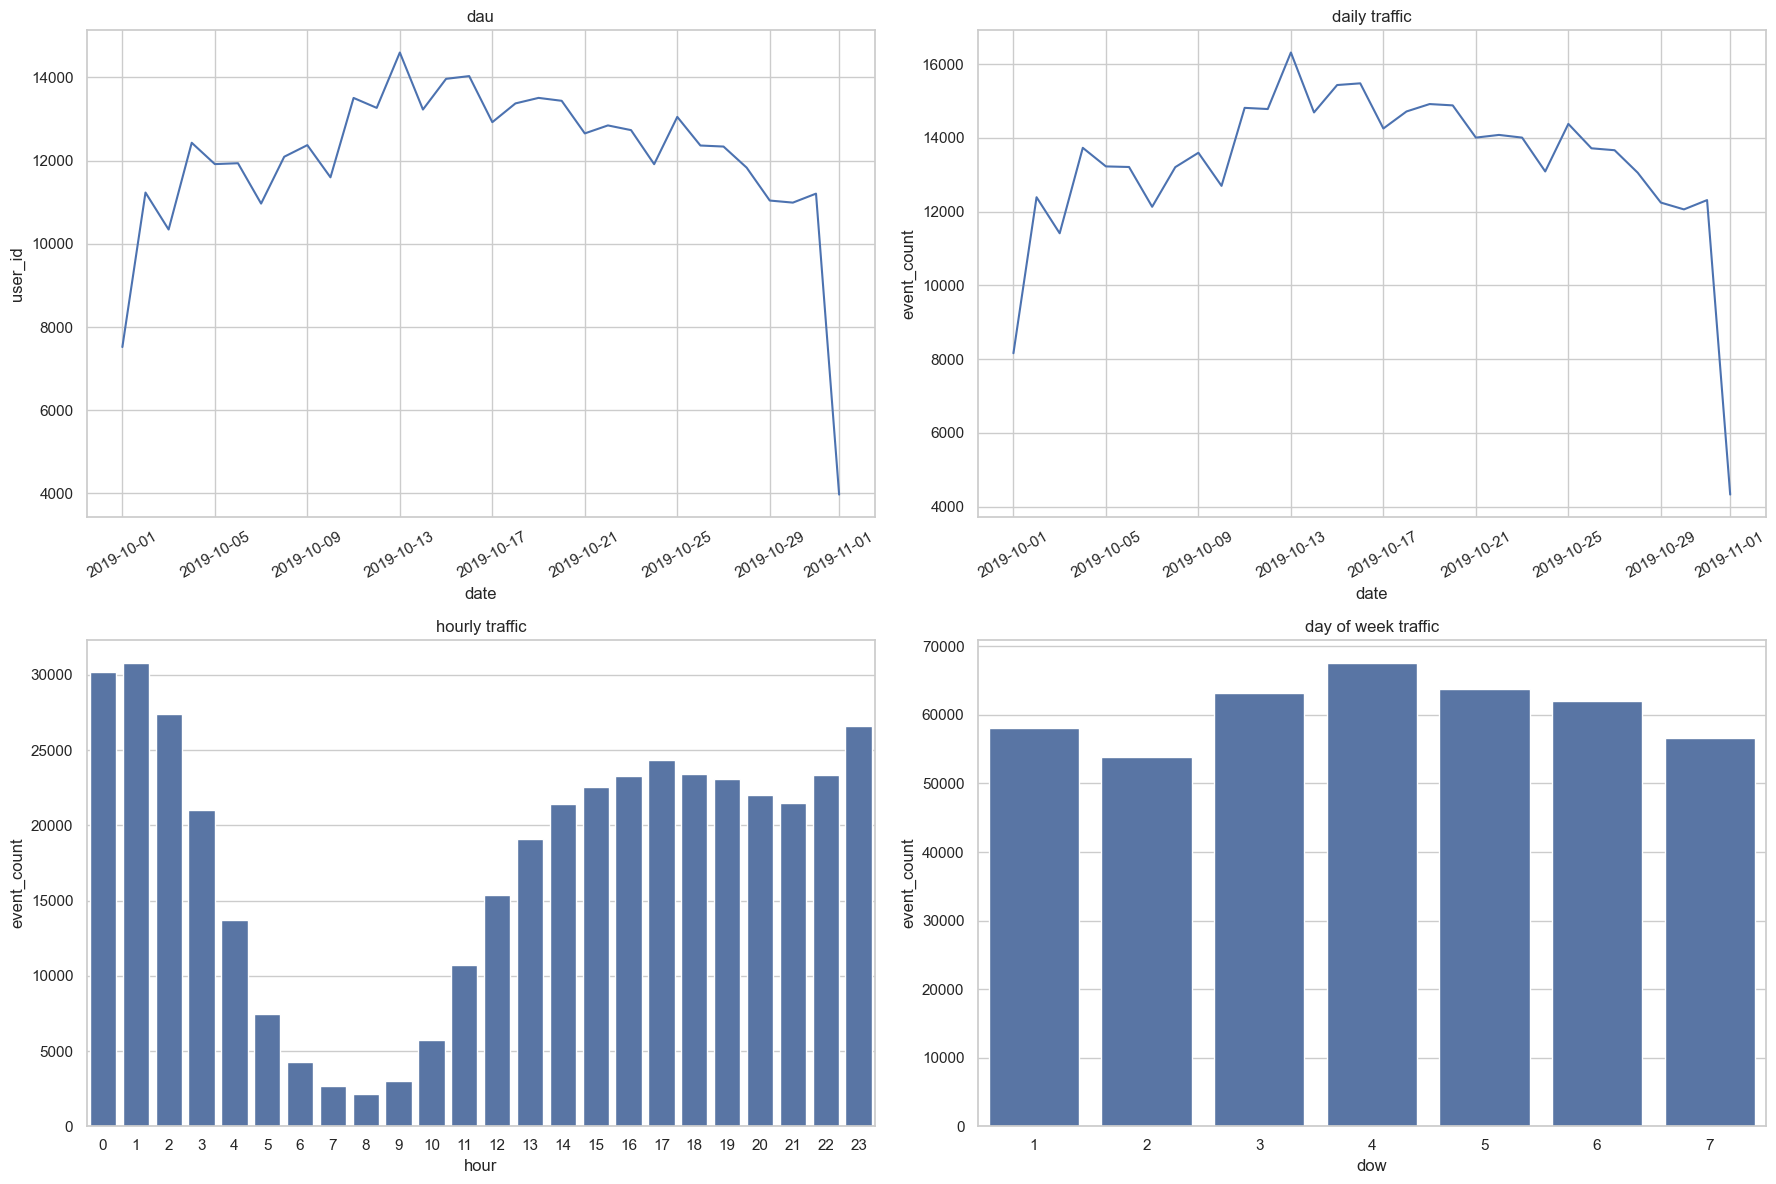

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

#dau
sns.lineplot(ax=axes[0,0], x=dau.index, y=dau.values)
axes[0,0].set_title("dau")
axes[0,0].set_xlabel("date")
axes[0,0].set_ylabel("user_id")
axes[0,0].tick_params(axis='x', rotation=30)

#day
sns.lineplot(ax=axes[0,1], x=traffic_daily.index, y=traffic_daily.values)
axes[0,1].set_title("daily traffic")
axes[0,1].set_xlabel("date")
axes[0,1].set_ylabel("event_count")
axes[0,1].tick_params(axis='x', rotation=30)


#hour
sns.barplot(ax=axes[1,0], x=traffic_hour.index, y=traffic_hour.values)
axes[1,0].set_title("hourly traffic")
axes[1,0].set_xlabel("hour")
axes[1,0].set_ylabel("event_count")

#dow
sns.barplot(ax=axes[1,1], x=traffic_dow.index, y=traffic_dow.values)
axes[1,1].set_title("day of week traffic")
axes[1,1].set_xlabel("dow")
axes[1,1].set_ylabel("event_count")

plt.tight_layout()
plt.show()

In [ ]:
#가격, 카테고리
#session length
#view_count

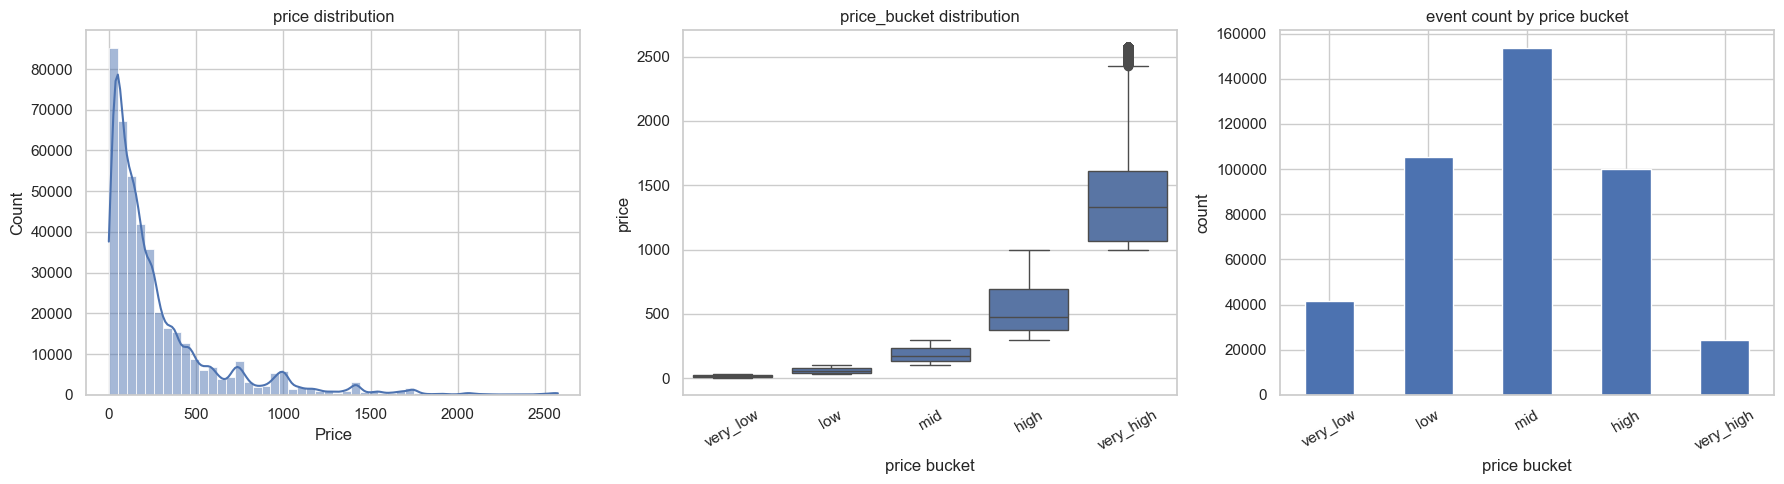

In [ ]:
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[0, 30, 100, 300, 1000, df['price'].max()],
    labels=['very_low', 'low', 'mid', 'high', 'very_high'],
    include_lowest=True
)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title("price distribution")
plt.xlabel("price")

plt.subplot(1,3,2)
sns.boxplot(x='price_bucket', y='price', data=df)
plt.title("price_bucket distribution")
plt.xlabel("price bucket")
plt.xticks(rotation=30)

plt.subplot(1,3,3)
df['price_bucket'].value_counts().sort_index().plot(kind='bar')
plt.title("event count by price bucket")
plt.xlabel("price bucket")
plt.ylabel("count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

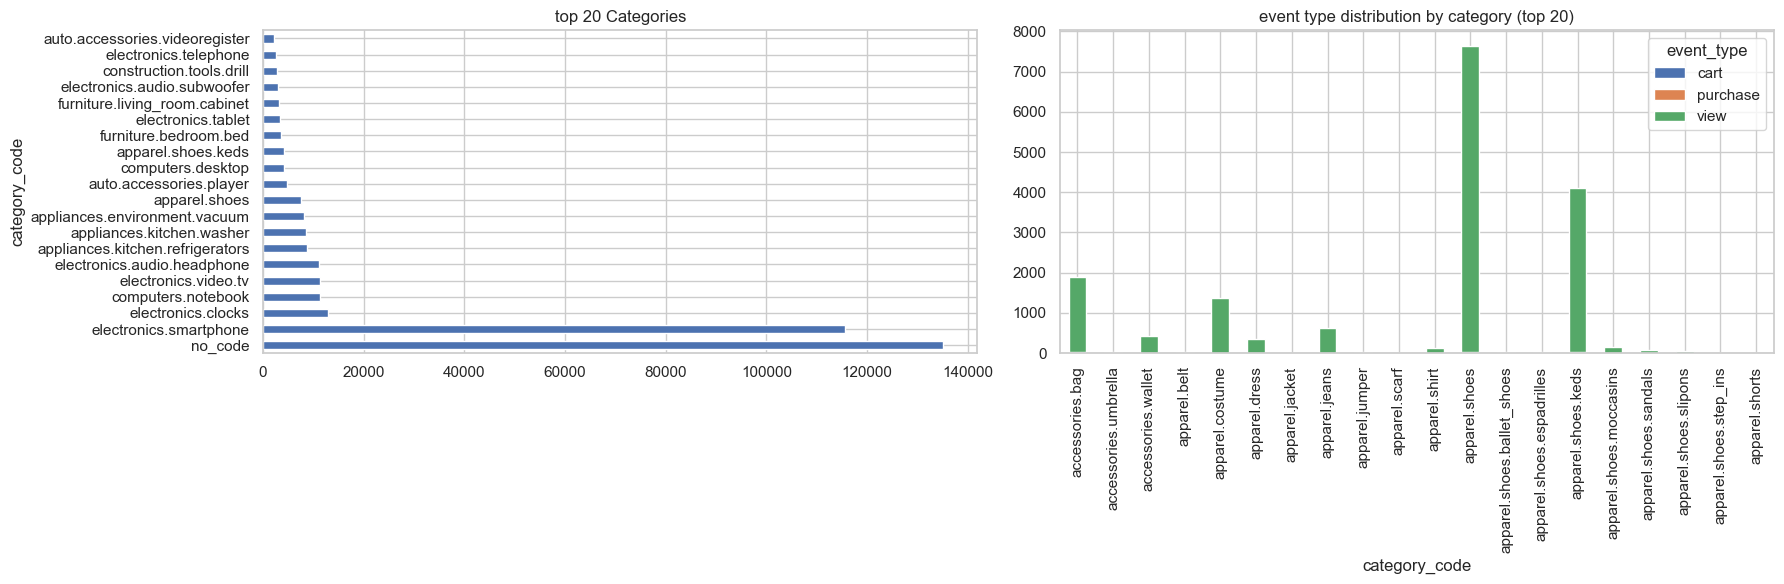

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df['category_code'].value_counts().head(20).plot(
    kind='barh', ax=axes[0]
)
axes[0].set_title("top 20 categories")
cat_event = df.groupby(['category_code','event_type']).size().unstack(fill_value=0)
cat_event.head(20).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("event type distribution by category (top 20)")

plt.tight_layout()
plt.show()

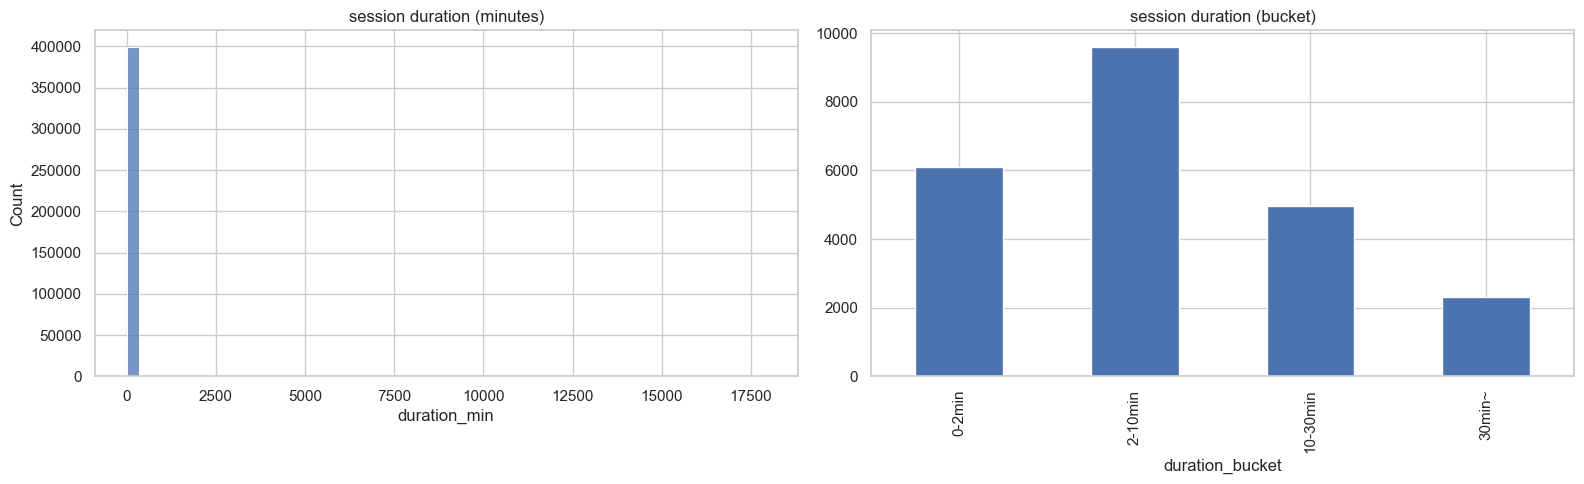

In [ ]:
session = df.groupby("user_session")['event_time'].agg(['min','max'])
session['duration_min'] = (session['max'] - session['min']).dt.total_seconds()/60

session['duration_bucket'] = pd.cut(
    session['duration_min'],
    bins=[0,2,10,30,999],
    labels=["0-2min","2-10min","10-30min","30min~"]
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(session['duration_min'], bins=50, ax=axes[0])
axes[0].set_title("session duration (minutes)")

session['duration_bucket'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title("session duration (bucket)")

plt.tight_layout()
plt.show()


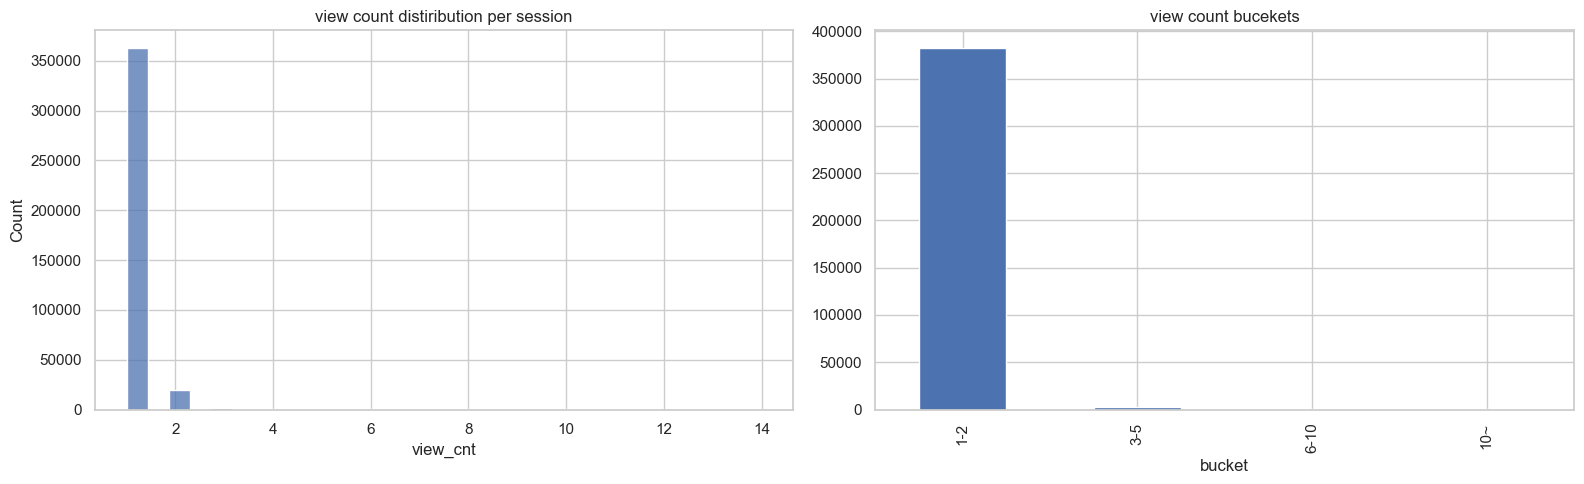

In [ ]:
view_count = df[df.event_type == 'view'].groupby("user_session").size()
vc = view_count.to_frame("view_cnt")
vc['bucket'] = pd.cut(vc['view_cnt'], [0,2,5,10,999], labels=["1-2","3-5","6-10","10~"])

fig, axes = plt.subplots(1, 2, figsize=(16,5))


sns.histplot(vc['view_cnt'], bins=30, ax=axes[0])
axes[0].set_title("view count distiribution per session")

vc['bucket'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title("view count bucekets")

plt.tight_layout()
plt.show()


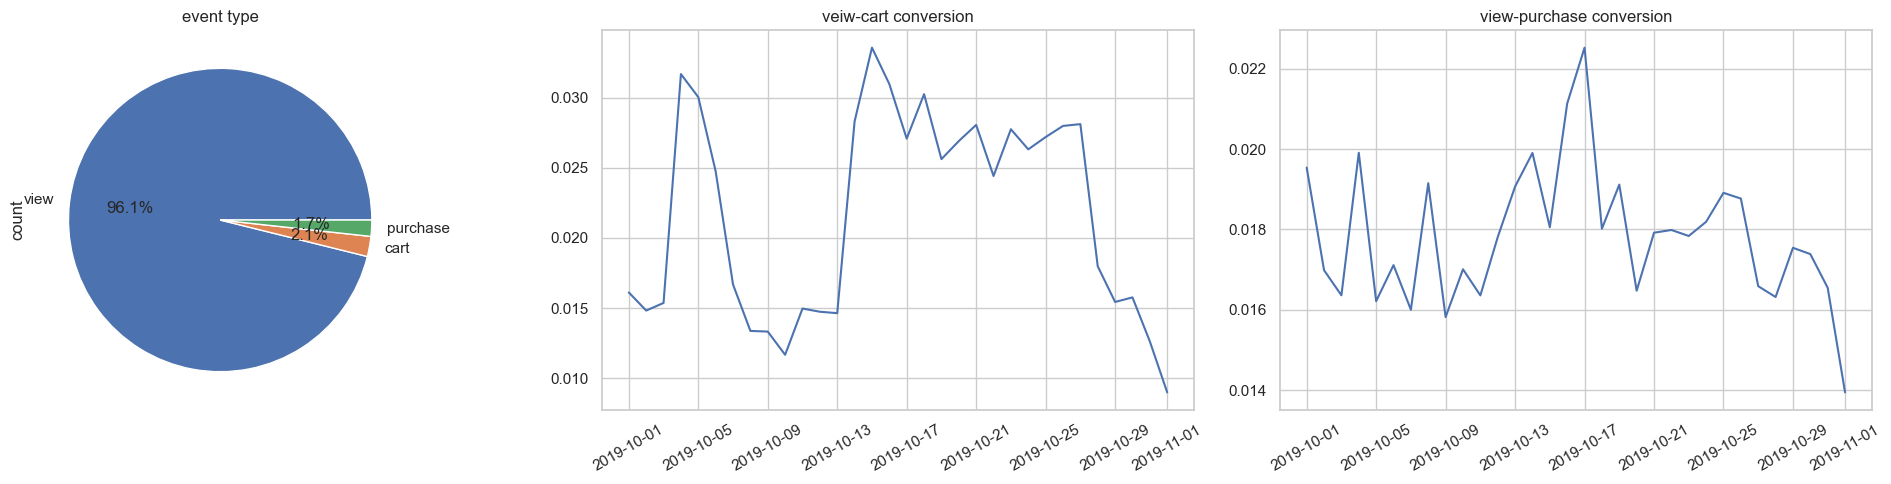

In [ ]:
daily = df.groupby(['event_date','event_type']).size().unstack(fill_value=0)

daily['view_to_cart'] = daily['cart'] / daily['view']
daily['view_to_purchase'] = daily['purchase'] / daily['view']

fig, axes = plt.subplots(1, 3, figsize=(20,5))

df['event_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title("event type")

axes[1].plot(daily.index, daily['view_to_cart'])
axes[1].set_title("veiw-cart conversion")
axes[1].tick_params(axis='x', rotation=30)

axes[2].plot(daily.index, daily['view_to_purchase'])
axes[2].set_title("view-purchase conversion")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
#mid 가격대 집중, 특정 카테고리 쏠림, no_code 불량 쏠림, view count 대부분, session 0-10 대부분
from google.cloud import bigquery
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
key_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = key_path

client = bigquery.Client()

In [2]:

#전체 전환율
query = """
SELECT *
FROM `ecommerce.d_funnel_summary`
"""
f_df = client.query(query).to_dataframe()

f_df

c:\Users\jiinss\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,vew_sessions,cart_sessions,purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,8893185,559560,279758,0.06292,0.499961,0.031458


In [5]:
#daily
daily_df = client.query("""
    SELECT *
    FROM `myetl-474505.ecommerce.d_daily_cohort`
    ORDER BY cohort_date
""").to_dataframe()

daily_df['cohort_date'] = pd.to_datetime(daily_df['cohort_date'])

c:\Users\jiinss\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
daily_df

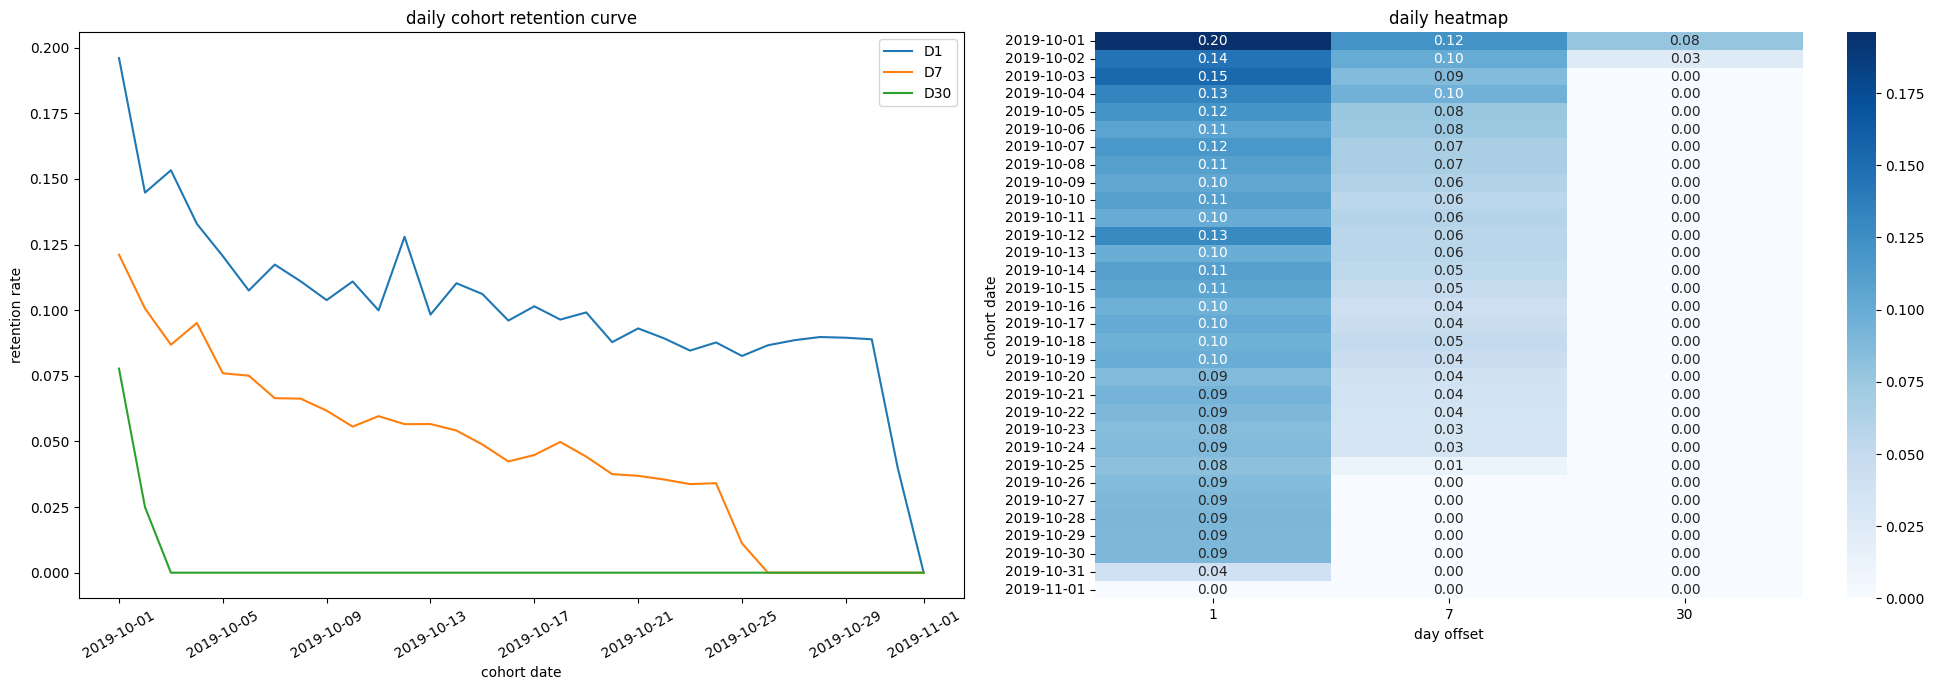

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.lineplot(data=daily_df, x='cohort_date', y='d1_retention', label='D1', ax=axes[0])
sns.lineplot(data=daily_df, x='cohort_date', y='d7_retention', label='D7', ax=axes[0])
sns.lineplot(data=daily_df, x='cohort_date', y='d30_retention', label='D30', ax=axes[0])

axes[0].set_title("daily cohort retention curve")
axes[0].set_xlabel("cohort date")
axes[0].set_ylabel("retention rate")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

daily_long = daily_df.melt(
    id_vars=['cohort_date'],
    value_vars=['d1_retention', 'd7_retention', 'd30_retention'],
    var_name='day_offset',
    value_name='retention'
)
daily_long['offset_num'] = daily_long['day_offset'].str.extract(r'(\d+)').astype(int)

daily_pivot = daily_long.pivot(
    index='cohort_date',
    columns='offset_num',
    values='retention'
).sort_index().sort_index(axis=1)

sns.heatmap(daily_pivot, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set_title("daily heatmap")
axes[1].set_xlabel("day offset")
axes[1].set_ylabel("cohort date")
axes[1].set_yticklabels([idx.strftime("%Y-%m-%d") for idx in daily_pivot.index])

plt.tight_layout()
plt.show()